## CS 363M: Machine Learning Project
The goal of this project is to predict whether an aircraft wildlife strike resulted in damage to the aircraft (`INDICATED_DAMAGE = 1`) or not (`INDICATED_DAMAGE = 0`).

## Our Approach
Our work is organized as following:
1. Load and inspect the data
2. Identify missing values and data quality issues
3. Drop columns that are too sparse, redundant, or difficult to use meaningfully
4. Clean and impute remaining values
5. Encode categorical variables
6. Train and compare models
7. Evaluate performance and iterate

In [1]:
# Standard Headers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

## Load the Data

We begin by loading the training and test datasets and setting a few common placeholder strings such as `"UNKNOWN"`, `"Unknown"`, and `"UNK"` to missing values. Treating these consistently as null values helps us measure which values are missing more accurately and makes later cleaning steps more reliable.

In [2]:
# Read in the data
train_data = pd.read_csv("data/train.csv", skipinitialspace=True, low_memory=False, na_values = ["UNKNOWN", "Unknown", "UNK"])
test_data = pd.read_csv("data/test.csv", skipinitialspace=True, low_memory=False, na_values=["UNKNOWN", "Unknown", "UNK"])

# Save the test ids for later use
test_ids = test_data["INDEX_NR"].copy()

# What percent of data values are null
print("Percent Null:", train_data.isnull().sum().sum() / (len(train_data) * len(train_data.columns)) * 100)

# Null amount for each column
print(train_data.isnull().sum())

Percent Null: 30.561646519429953
INDEX_NR                     0
INCIDENT_DATE                0
INCIDENT_MONTH               0
INCIDENT_YEAR                0
TIME                    132042
TIME_OF_DAY             133971
AIRPORT_ID                   0
AIRPORT                  40684
LATITUDE                 40744
LONGITUDE                40747
RUNWAY                   75586
STATE                    40744
FAAREGION                40744
LOCATION                267965
OPID                     86692
OPERATOR                 86692
REG                     118999
FLT                     161442
AIRCRAFT                 86942
AMA                      88896
AMO                     116813
EMA                     102421
EMO                     113176
AC_CLASS                 87315
AC_MASS                  87446
TYPE_ENG                 87786
NUM_ENGS                 87697
ENG_1_POS                87717
ENG_2_POS               102509
ENG_3_POS               294822
ENG_4_POS               303909
PHASE_

## Drop Columns with Excessive Missing Values

Our first cleaning decision is to remove columns that are missing at least 50% of their values. When a feature is mostly empty, it is hard to use reliably without making assumptions during imputation.

We chose this threshold as a way to reduce noise and simplify the feature space. Rather than forcing imputation on extremely sparse columns, we keep the features that contain enough information to be useful.

Dropping a sparse column may remove some signal, but keeping too many incomplete variables can also hurt model quality and make the pipeline harder to interpret.

In [3]:
def get_sparse_cols(df):
    sparse_cols = []

    for col in df.columns:
        if df[col].isnull().sum() >= len(df) / 2:
            sparse_cols.append(col)

    return sparse_cols

def drop_sparse_cols(df, sparse_cols):
    df = df.copy()

    # For each column, drop the column if it has 50% or more of its data missing
    print("Before:", len(df.columns))

    for col in sparse_cols:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)
            print("Dropped:", col)

    print("After:", len(df.columns))
    return df

In [4]:
sparse_cols = get_sparse_cols(train_data)

print("Dropping sparse columns for train data")
train_data = drop_sparse_cols(train_data, sparse_cols)

print("\nDropping sparse columns for test data")
test_data = drop_sparse_cols(test_data, sparse_cols)

Dropping sparse columns for train data
Before: 55
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SPEED
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 43

Dropping sparse columns for test data
Before: 54
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SPEED
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 42


## Remove Redundant or Overlapping Features

Next, we remove several columns that appear to overlap heavily with other features we plan to keep. For example, some text columns have other equivalents, and some location fields overlap with latitude and longitude.

Such as:
- `AIRPORT` overlaps with `AIRPORT_ID` / coordinates
- `OPERATOR` overlaps with `OPID`
- `SPECIES` overlaps with `SPECIES_ID`

Our goal is to reduce redundancy and avoid giving the model multiple versions of the same information.

In [5]:
def drop_redundant_cols(df):
    df = df.copy()

    print("Before:", len(df.columns))

    for col in ["AIRPORT", "OPERATOR", "SPECIES"]:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)

    print("After:", len(df.columns))
    return df

In [6]:
print("Dropping redundant columns for train data")
train_data = drop_redundant_cols(train_data)

print("\nDropping redundant columns for test data")
test_data = drop_redundant_cols(test_data)

Dropping redundant columns for train data
Before: 43
After: 40

Dropping redundant columns for test data
Before: 42
After: 39


## Drop columns that are difficult to use or not likely to generalize well

In addition to sparse/redundant columns, we also remove a set of features that are less useful for modeling. These include:
- free-text fields
- identifiers
- administrative metadata
- columns with very limited variation
- columns that are difficult to generalize in a simple model

In [7]:
def drop_selected_cols(df):
    df = df.copy()
    
    print("Before:", len(df.columns))

    DROP_COLS = [
        "REMARKS", "REMAINS_SENT", "COMMENTS", "SOURCE", 
        "PERSON", "LUPDATE", "TRANSFER", "NUM_STRUCK", 
        "FAAREGION", "INCIDENT_DATE", "REG", "INDEX_NR", 
        "ENG_1_POS", "ENG_2_POS", "AIRCRAFT", "AMA", 
        "AMO", "EMA", "EMO", "AC_CLASS"
    ]

    for col in DROP_COLS:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)

    print("After:", len(df.columns))
    return df

In [8]:
print("Dropping selected columns for train data")
train_data = drop_selected_cols(train_data)

print("\nDropping selected columns for test data")
test_data = drop_selected_cols(test_data)

Dropping selected columns for train data
Before: 40
After: 20

Dropping selected columns for test data
Before: 39
After: 19


## Why we dropped these columns

These decisions were made to keep the feature set interpretable and to reduce noise before modeling.

In [9]:
"""
REMARKS, COMMENTS: 
Additional notes on the incident that would be difficult to quantify within a ML model

REMAINS_SENT, SOURCE, PERSON, LUPDATE, TRANSFER, REG:
Not very predictive of if there was damage to the aircraft

NUM_STRUCK:
89% of the data was the same, and almost all of the rest was corrupted

FAAREGION:
We decided to use LONG and LAT instead

INCIDENT_DATE: 
This is less relevant than other time values that we decided to keep

INDEX_NR: 
This is a separate index and would skew our result if kept

ENG_1_POS, ENG_2_POS, AIRCRAFT, AMA, AMO, EMA, EMO:
Dropped due to a combination of many missing values and a difficulty to generalize this across different aircrafts

AC_CLASS: 
70% of the data is an aircraft, 2 records total are helicopters, rest is unknown. So this is not very helpful
"""

'\nREMARKS, COMMENTS: \nAdditional notes on the incident that would be difficult to quantify within a ML model\n\nREMAINS_SENT, SOURCE, PERSON, LUPDATE, TRANSFER, REG:\nNot very predictive of if there was damage to the aircraft\n\nNUM_STRUCK:\n89% of the data was the same, and almost all of the rest was corrupted\n\nFAAREGION:\nWe decided to use LONG and LAT instead\n\nINCIDENT_DATE: \nThis is less relevant than other time values that we decided to keep\n\nINDEX_NR: \nThis is a separate index and would skew our result if kept\n\nENG_1_POS, ENG_2_POS, AIRCRAFT, AMA, AMO, EMA, EMO:\nDropped due to a combination of many missing values and a difficulty to generalize this across different aircrafts\n\nAC_CLASS: \n70% of the data is an aircraft, 2 records total are helicopters, rest is unknown. So this is not very helpful\n'

## Re-check missing values after removing columns

After dropping the noisiest/sparsest columns, we inspected missing values again. Since the remaining missing values are more manageable, we do imputation based on the type of variable and the context of the data.

In [10]:
print(train_data.isnull().sum()[train_data.isnull().sum() > 0] / len(train_data) * 100)

TIME               42.985500
TIME_OF_DAY        43.613475
LATITUDE           13.263971
LONGITUDE          13.264947
RUNWAY             24.606580
STATE              13.263971
OPID               28.222073
AC_MASS            28.467533
TYPE_ENG           28.578218
NUM_ENGS           28.549245
PHASE_OF_FLIGHT    39.381075
DISTANCE           33.629687
SIZE               10.908008
dtype: float64


## Cleaning and Imputing Features

Instead of applying one generic fill strategy to everything, we use more targeted methods based on the meaning of each variable.

We did the following:
- correct formatting issues in latitude and longitude
- fill missing geographic values using airport and state information
- convert time into a numeric hour feature and impute missing values using time of day groups
- fill missing distance values using phase of flight
- prepare these features so they can be used more effectively during modeling

In [11]:
def fix_lat_long_format(df):
    df = df.copy()

    # Find the comma errors where latitude and longitude were combined
    comma_errors = df["LATITUDE"].str.contains(",", na=False)
    vals_with_com_errs = df.loc[comma_errors, "LATITUDE"].str.split(",", expand=True)

    # Fix the comma errors
    df.loc[comma_errors, "LATITUDE"] = vals_with_com_errs[0]
    df.loc[comma_errors, "LONGITUDE"] = vals_with_com_errs[1]

    return df

In [12]:
def fill_lat_long(df, fit=True, stats=None):
    df = df.copy()

    # Make LAT and LONG numeric floats
    df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
    df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")

    if fit:
        stats = {}

        for col in ["LATITUDE", "LONGITUDE"]:
            stats[col] = {
                "airport": df.groupby("AIRPORT_ID")[col].median(),
                "state": df.groupby("STATE")[col].median(),
                "global": df[col].median()
            }

    # Fill using TRAIN stats
    for col in ["LATITUDE", "LONGITUDE"]:
        df[col] = df[col].fillna(df["AIRPORT_ID"].map(stats[col]["airport"]))
        df[col] = df[col].fillna(df["STATE"].map(stats[col]["state"]))
        df[col] = df[col].fillna(stats[col]["global"])

    df.drop("AIRPORT_ID", inplace=True, axis=1, errors="ignore")
    df.drop("STATE", inplace=True, axis=1, errors="ignore")

    if fit:
        return df, stats
    return df

In [13]:
def clean_time(df, fit=True, stats=None):
    df = df.copy()

    # Extracting out the hour value from the time column
    df["TIME"] = pd.to_datetime(df["TIME"], format="%H:%M", errors="coerce").dt.round("h").dt.hour

    if fit:
        stats = {}
        stats["time_by_period"] = df.groupby("TIME_OF_DAY")["TIME"].median()
        stats["global_time"] = df["TIME"].median()

    # Filling missing TIME values with the median value of it's TIME_OF_DAY
    df["TIME"] = df["TIME"].fillna(df["TIME_OF_DAY"].map(stats["time_by_period"]))

    # Filling rest of missing TIME values with median time
    df["TIME"] = df["TIME"].fillna(stats["global_time"])

    # Drop TIME_OF_DAY column  
    df.drop("TIME_OF_DAY", inplace=True, axis=1, errors="ignore")

    if fit:
        return df, stats
    
    return df

In [14]:
def clean_distance(df, fit=True, stats=None):
    df = df.copy()

    if fit:
        stats = {}
        stats["phase"] = df.groupby("PHASE_OF_FLIGHT")["DISTANCE"].median()
        stats["global"] = df["DISTANCE"].median()

    # Use PHASE_OF_FLIGHT to fill in nans for DISTANCE
    df["DISTANCE"] = df["DISTANCE"].fillna(df["PHASE_OF_FLIGHT"].map(stats["phase"]))

    # Just use median DISTANCE for nans if PHASE_OF_FLIGHT is also missing for this data point
    df["DISTANCE"] = df["DISTANCE"].fillna(stats["global"])

    if fit:
        return df, stats
    
    return df

In [15]:
def clean_features(df, fit=True, stats=None):
    df = df.copy()
    
    print("Before:", len(df.columns))

    # Fix formatting
    df = fix_lat_long_format(df)

    if fit:
        stats = {}
        df, stats["geo"] = fill_lat_long(df, fit=True)
        df, stats["time"] = clean_time(df, fit=True)
        df, stats["distance"] = clean_distance(df, fit=True)

    else:
        df = fill_lat_long(df, fit=False, stats=stats["geo"])
        df = clean_time(df, fit=False, stats=stats["time"])
        df = clean_distance(df, fit=False, stats=stats["distance"])

    print("After:", len(df.columns))
    print(df.isnull().sum() / len(df) * 100)

    if fit:
        return df, stats
    
    return df

In [16]:
print("Cleaning features for train data")
train_data, feature_stats = clean_features(train_data, fit=True)

print("\nCleaning features for test data")
test_data = clean_features(test_data, fit=False, stats=feature_stats)

Cleaning features for train data
Before: 20
After: 17
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                     0.000000
LATITUDE                 0.000000
LONGITUDE                0.000000
RUNWAY                  24.606580
OPID                    28.222073
AC_MASS                 28.467533
TYPE_ENG                28.578218
NUM_ENGS                28.549245
PHASE_OF_FLIGHT         39.381075
DISTANCE                 0.000000
SPECIES_ID               0.000000
OUT_OF_RANGE_SPECIES     0.000000
REMAINS_COLLECTED        0.000000
SIZE                    10.908008
INDICATED_DAMAGE         0.000000
dtype: float64

Cleaning features for test data
Before: 19
After: 16
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                     0.000000
LATITUDE                 0.000000
LONGITUDE                0.000000
RUNWAY                  24.362017
OPID                    28.569336
AC_MASS                 28.856465
TYPE_ENG                28.

Filling remaining missing values

In [17]:
def fill_missing_values(df, fit=True, stats=None, top_ops=None):
    df = df.copy()

    print("Before:", len(df.columns))

    # Convert runway to is or isn't airborne
    df["AIRBORNE"] = df["RUNWAY"].isnull().astype(int)
    df.drop("RUNWAY", inplace=True, axis=1, errors="ignore")

    # Fill in missing SIZE
    df["SIZE"] = df["SIZE"].fillna("UNK")
    df.drop("SPECIES_ID", inplace=True, axis=1, errors="ignore")

    if fit:
        if top_ops is None:
            top_ops = df["OPID"].value_counts().nlargest(10).index

        stats = {
            "num_engs_median": df["NUM_ENGS"].median(),
            "ac_mass_median": df["AC_MASS"].median(),
            "type_eng_mode": df["TYPE_ENG"].mode()[0]
        }

    # Reduce cardinality of OPID
    df["OPID"] = df["OPID"].where(
        df["OPID"].isin(top_ops), "UNK"
    )

    # Add missing values for PHASE_OF_FLIGHT
    df["PHASE_OF_FLIGHT"] = df["PHASE_OF_FLIGHT"].fillna("MISSING")

    # Fill in missing values using TRAIN stats
    df["NUM_ENGS"] = df["NUM_ENGS"].fillna(stats["num_engs_median"])
    df["AC_MASS"] = df["AC_MASS"].fillna(stats["ac_mass_median"])
    df["TYPE_ENG"] = df["TYPE_ENG"].fillna(stats["type_eng_mode"])

    print("After:", len(df.columns))
    print(df.isnull().sum() / len(df) * 100)

    if fit:
        return df, top_ops, stats
    return df

In [18]:
print("Filling missing values for train data")
train_data, top_ops, fill_stats = fill_missing_values(train_data, fit=True)

print("\nFilling missing values for test data")
test_data = fill_missing_values(test_data, fit=False, stats=fill_stats, top_ops=top_ops)

Filling missing values for train data
Before: 17
After: 16
INCIDENT_MONTH          0.0
INCIDENT_YEAR           0.0
TIME                    0.0
LATITUDE                0.0
LONGITUDE               0.0
OPID                    0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
PHASE_OF_FLIGHT         0.0
DISTANCE                0.0
OUT_OF_RANGE_SPECIES    0.0
REMAINS_COLLECTED       0.0
SIZE                    0.0
INDICATED_DAMAGE        0.0
AIRBORNE                0.0
dtype: float64

Filling missing values for test data
Before: 16
After: 15
INCIDENT_MONTH          0.0
INCIDENT_YEAR           0.0
TIME                    0.0
LATITUDE                0.0
LONGITUDE               0.0
OPID                    0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
PHASE_OF_FLIGHT         0.0
DISTANCE                0.0
OUT_OF_RANGE_SPECIES    0.0
REMAINS_COLLECTED       0.0
SIZE                    0.0
AIRBORNE                0.0

## Identify Categorical Features

Before encoding, we identify which remaining columns should be treated as categorical. This matters because machine learning models generally require numeric input, but not all variables should be converted the same way.

In [19]:
def identify_categorical_cols(df):
    categorical_cols = []
    numeric_cols = []

    for col in df.columns:
        # Try converting column to numeric
        converted = pd.to_numeric(df[col], errors='coerce')
        
        # If any portion becomes NaN, it's categorical
        num_na = converted.isnull().sum()
        
        if num_na > 1:
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)

    print("Categorical Columns:")
    print(categorical_cols)

    print("\nNumeric Columns:")
    print(numeric_cols)

    print("\nTypes of the column data:")
    print(df.dtypes)

    return categorical_cols

In [20]:
print("Identifying categorical columns from train data")
categorical_cols = identify_categorical_cols(train_data)

Identifying categorical columns from train data
Categorical Columns:
['OPID', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SIZE']

Numeric Columns:
['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'LATITUDE', 'LONGITUDE', 'AC_MASS', 'NUM_ENGS', 'DISTANCE', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'INDICATED_DAMAGE', 'AIRBORNE']

Types of the column data:
INCIDENT_MONTH            int64
INCIDENT_YEAR             int64
TIME                    float64
LATITUDE                float64
LONGITUDE               float64
OPID                     object
AC_MASS                 float64
TYPE_ENG                 object
NUM_ENGS                float64
PHASE_OF_FLIGHT          object
DISTANCE                float64
OUT_OF_RANGE_SPECIES      int64
REMAINS_COLLECTED         int64
SIZE                     object
INDICATED_DAMAGE          int64
AIRBORNE                  int64
dtype: object


## Encoding Categorical Features

Initially, we encoded all categorical variables using **one-hot encoding**. This approach is simple and works well for models because it does not create any ordering between categories.

In [21]:
def encode_cols(df, categorical_cols, fit=True, encoders=None):
    df = df.copy()

    if "INDICATED_DAMAGE" in df.columns:
        X = df.drop("INDICATED_DAMAGE", axis=1).copy()
        y = df["INDICATED_DAMAGE"].copy()
    else:
        X = df.copy()
        y = None

    print("Number of rows and cols before encoding:", X.shape)

    if fit:
        high_card_cols = []
        low_card_cols = []

        for col in categorical_cols:
            num_unique = X[col].nunique()

            # Threshold: > 10 unique values, high cardinality
            if num_unique > 10:
                high_card_cols.append(col)
            else:
                low_card_cols.append(col)

        print("High-cardinality columns (frequency encode):", high_card_cols)
        print("Low-cardinality columns (one-hot encode):", low_card_cols)

        freq_maps = {}

        # Frequency encode for high-cardinality columns
        for col in high_card_cols:
            freq = X[col].value_counts(normalize=True)
            freq_maps[col] = freq
            X[col] = X[col].map(freq)

        # One-hot encode for low-cardinality columns
        X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=False)

        encoders = {
            "high_card_cols": high_card_cols,
            "low_card_cols": low_card_cols,
            "freq_maps": freq_maps,
            "train_cols": X_encoded.columns
        }

        print("Final shape after encoding:", X_encoded.shape)
        return X_encoded, y, encoders

    else:
        high_card_cols = encoders["high_card_cols"]
        low_card_cols = encoders["low_card_cols"]
        freq_maps = encoders["freq_maps"]
        train_cols = encoders["train_cols"]

        # Frequency encode using train frequencies
        for col in high_card_cols:
            X[col] = X[col].map(freq_maps[col]).fillna(0)

        # One-hot encode
        X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=False)

        # Align columns to training columns
        X_encoded = X_encoded.reindex(columns=train_cols, fill_value=0)

        print("Final shape after encoding:", X_encoded.shape)
        return X_encoded

In [22]:
print("Encoding columns for train data")
X_encoded, y, encoders = encode_cols(train_data, categorical_cols, fit=True)

print("\nEncoding columns for test data")
X_test_encoded = encode_cols(test_data, categorical_cols, fit=False, encoders=encoders)

Encoding columns for train data
Number of rows and cols before encoding: (307178, 15)
High-cardinality columns (frequency encode): ['OPID', 'PHASE_OF_FLIGHT']
Low-cardinality columns (one-hot encode): ['TYPE_ENG', 'SIZE']
Final shape after encoding: (307178, 24)

Encoding columns for test data
Number of rows and cols before encoding: (34131, 15)
Final shape after encoding: (34131, 24)


## Neural Nets

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Split the training data into train and validation splits (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

# Scale the features for the neural network
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

# Compute the class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    class_weight=class_weights
)

# Predict probabilities on the validation set
val_probs = model.predict(X_val).flatten()

best_t = None
thresholds = [0.3, 0.4, 0.5, 0.6]
best_score = -1
scores = []

for t in thresholds:
    val_preds = (val_probs > t).astype(int)
    score = balanced_accuracy_score(y_val, val_preds)
    scores.append(score)

    if score > best_score:
        best_score = score
        best_t = t
        
    print(t, score)

/Users/karenheckel/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{0: np.float64(0.5339431600903877), 1: np.float64(7.865254128792728)}
Epoch 1/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5062 - precision_2: 0.1644 - recall_2: 0.7874 - val_loss: 0.4708 - val_precision_2: 0.1820 - val_recall_2: 0.8223
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4523 - precision_2: 0.1869 - recall_2: 0.8069 - val_loss: 0.4547 - val_precision_2: 0.1968 - val_recall_2: 0.8036
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4437 - precision_2: 0.1939 - recall_2: 0.8049 - val_loss: 0.4253 - val_precision_2: 0.2088 - val_recall_2: 0.7800
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4412 - precision_2: 0.1969 - recall_2: 0.7951 - val_loss: 0.4379 - val_precision_2: 0.2040 - val_recall_2: 0.7933
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4417 - precision_2: 0.1997 - recall_2: 0.8033 - val_loss: 0.4272 - val_precision_2: 0.2075 - val_recall_2: 0.7923
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/ste

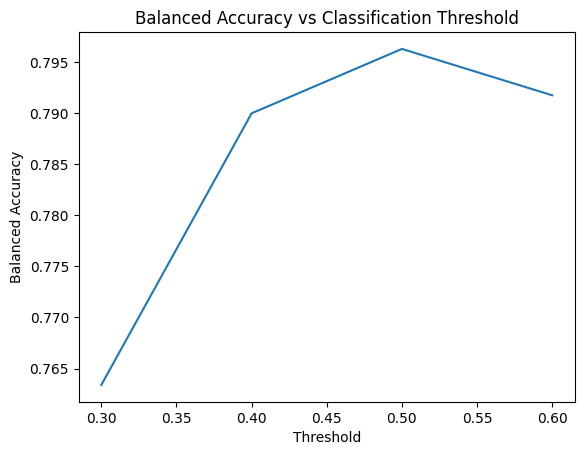

In [29]:
# Plot threshold vs balanced accuracy
plt.plot(thresholds, scores)
plt.xlabel("Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy vs Classification Threshold")
plt.show()

In [27]:
# Scale the Kaggle test data with the SAME scaler fit on X_train
X_test_scaled = scaler.transform(X_test_encoded)

# Predict probabilities on test data
test_probs = model.predict(X_test_scaled)

# Convert probabilities to 0/1 predictions
test_preds = (test_probs > best_t).astype(int)

# Build the submission file
submission = pd.DataFrame({
    "INDEX_NR": test_ids,
    "INDICATED_DAMAGE": test_preds.flatten()
})

submission.to_csv("submission_nn.csv", index=False)

print(submission.head())
print(submission["INDICATED_DAMAGE"].value_counts())

1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step
   INDEX_NR  INDICATED_DAMAGE
0   9000000                 0
1   9000001                 0
2   9000002                 0
3   9000003                 0
4   9000004                 1
INDICATED_DAMAGE
0    26388
1     7743
Name: count, dtype: int64
